**FCD - Projeto prático - TP - 26/1**

**Data de entrega**: 26/jun/2026
**Trabalho em dupla** - favor colocar o nome no cabeçalho do seu projeto (notebook) a ser entregue.

**Nome 1**: Ana Luiza Gonçalves Campos

**Nome 2**: Gabriel Costa Reis


✅**Parte 1 - Preparo inicial do projeto (já pronto para uso no projeto)**

Pegar CSVs da base de dados e carregar. Nesta etapa, o objetivo é importar as bibliotecas essenciais e carregar as duas tabelas principais diretamente do repositório público: a tabela de Torneios (resumo de cada Copa) e a de Partidas (detalhes de cada jogo).

**Instruções do projeto prático**

Documentação do Projeto: Análise Científica e Preditiva das Copas do Mundo FIFA
Este projeto é uma exploração completa de ponta a ponta (End-to-End) do histórico das Copas do Mundo de Futebol masculino, indo desde a extração bruta dos dados até a aplicação de modelos de Machine Learning com explicabilidade algorítmica (XAI). Ele foi estruturado para ser executado em um ambiente de notebook (como Jupyter ou Google Colab) e utiliza as principais bibliotecas do ecossistema Python para Ciência de Dados.

Abaixo, detalhamos a arquitetura do projeto e as bases de dados utilizadas.

📂 1. As Bases de Dados Envolvidas
O projeto consome dados abertos do repositório Fjelstul World Cup, uma base amplamente reconhecida na comunidade acadêmica por sua limpeza e padronização. Duas tabelas principais em formato CSV são ingeridas diretamente via URL:

tournaments.csv (Resumo das Edições): Contém os metadados de cada edição da Copa do Mundo (de 1930 até a atualidade).

Principais Variáveis: year (Ano), host_country (País Sede), winner (Campeão), num_teams (Total de seleções participantes).

matches.csv (Microdados das Partidas): O núcleo da análise. Contém o registro individual de cada jogo disputado na história do torneio.

Principais Variáveis: match_date (Data), stage_name (Fase do torneio), home_team_name e away_team_name (Seleções mandante e visitante), home_team_score e away_team_score (Placar), extra_time (Indicador de prorrogação), penalty_shootout (Indicador de pênaltis), attendance (Público pagante).

🏗️ 2. Arquitetura e Etapas do Projeto
O notebook foi desenhado em 6 grandes blocos lógicos, simulando o fluxo de trabalho real de um Cientista de Dados:

✅**Parte 1:** Ingestão, Limpeza e Engenharia de Atributos (Setup)
Objetivo: Preparar o terreno para a análise.

O que é feito: Os dados crus são lidos do GitHub usando a biblioteca pandas. Realiza-se o cruzamento (Left Join) da tabela de partidas com a tabela de torneios para associar o país sede e o ano a cada jogo específico.

Engenharia de Atributos (Feature Engineering): Novas variáveis cruciais são criadas matematicamente a partir das originais, como total_goals (soma do placar) e goal_difference (diferença absoluta de gols).

✅**Parte 2:** Análise Exploratória e Manipulação de Dados Avançada
Objetivo: Extrair insights descritivos complexos manipulando a estrutura dos dados.

O que é feito: Transforma-se o formato da base de "uma linha por jogo" para "uma linha por equipe por jogo" (df_equipes), permitindo analisar o desempenho isolado de cada país.

Técnicas aplicadas: Agrupamentos (groupby), filtros booleanos condicionais cruzados, tabelas de frequência e funções personalizadas aplicadas com .apply(). Responde-se a questões de negócio como: as maiores vítimas de gols, as zebras históricas e a evolução ofensiva das equipes na fase de grupos.

✅**Parte 3:** Visualização de Dados (Data Storytelling)
Objetivo: Traduzir os números em padrões visuais compreensíveis através do matplotlib e seaborn.

O que é feito: Construção de gráficos de alta densidade informativa.

KDE/Histogramas: Para ver a assimetria na distribuição de gols.

Barras Empilhadas: Para entender a evolução temporal das decisões por pênaltis.

Violin Plots: Para comparar a regularidade técnica entre grandes potências (Brasil, Alemanha, etc.).

Heatmaps (Mapas de Calor): Para cruzar variáveis categóricas temporais (Edições vs. Fases do Torneio).

✅**Parte 4:** Correlações Estatísticas
Objetivo: Comprovar matematicamente se intuições esportivas são verdadeiras.

O que é feito: Uso da biblioteca scipy.stats para calcular correlações que não assumem normalidade dos dados (Correlação de Spearman).

Aplicações: Provar estatisticamente a tese de que o futebol se tornou mais defensivo com o tempo (Ano x Gols), ou se jogos eliminatórios mais avançados (maior pressão) têm correlação positiva direta com a ida para as cobranças de pênalti.

✅**Parte 5:** Inferência, Probabilidade e Estatística Avançada
Objetivo: Elevar o rigor matemático do projeto, saindo do descritivo empírico para o campo teórico e probabilístico.

O que é feito: * Distribuição de Poisson: Modela-se a probabilidade teórica de um jogo terminar em 0x0 comparando-a com a realidade histórica.

Teorema de Bayes (Probabilidade Condicional): Calcula-se a probabilidade de um jogo ir para os pênaltis dado que já está na prorrogação.

Teste de Hipótese (T-Test): Aplica-se um teste formal para validar o futebol está ficando mais equilibrado.
Vamos calcular a correlação entre o passar do tempo (Ano da Copa) e o Equilíbrio (Diferença de Gols). As famosas goleadas acachapantes ficaram no passado? E aferir para isso o p-value.

✅**Parte 6:** Inteligência Artificial e Explicabilidade (XAI)
Objetivo: Treinar algoritmos capazes de generalizar padrões e prever resultados, com total transparência algorítmica.

O que é feito: Uso do scikit-learn para separar os dados em treino e teste.

Regressão Linear Múltipla: Modelo para prever o Total de Gols de uma partida futura utilizando as exatas variáveis independentes.

Random Forest: Um modelo de árvore de decisão ensemble treinado para classificar e prever se o time mandante sairá vitorioso, baseado no histórico de ataque e defesa das equipes envolvidas.

Explainable AI (SHAP): Utilização da biblioteca shap (Shapley Additive exPlanations) para "abrir a caixa preta" do modelo Random Forest. Isso gera um gráfico que explica exatamente o peso e o impacto que cada variável (ex: poder de defesa do visitante vs. poder de ataque do mandante) teve para a decisão final da Inteligência Artificial.

In [1]:
# Instalação de pacotes auxiliares (descomente se rodar no Colab)
#!pip install shap scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")

# 1. Carregamento dos dados
url_torneios = "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv/tournaments.csv"
url_partidas = "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv/matches.csv"

df_torneios = pd.read_csv(url_torneios)
df_partidas = pd.read_csv(url_partidas)

# 2. Estruturação e Limpeza (Merge)
df_partidas['match_date'] = pd.to_datetime(df_partidas['match_date'])
df_partidas['total_goals'] = df_partidas['home_team_score'] + df_partidas['away_team_score']
df_partidas['goal_difference'] = abs(df_partidas['home_team_score'] - df_partidas['away_team_score'])

# Trazendo o país sede e o ano do torneio para a base de partidas
df_consolidado = pd.merge(
    df_partidas,
    df_torneios[['tournament_id', 'year', 'host_country', 'winner']],
    on='tournament_id',
    how='left'
)

print("Setup concluído! Base pronta para análise.")

display(df_consolidado.head())

Setup concluído! Base pronta para análise.


,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,...,away_team_score_penalties,result,home_team_win,away_team_win,draw,total_goals,goal_difference,year,host_country,winner
0,1,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,...,0,home team win,1,0,0,5,3,1930,Uruguay,Uruguay
1,2,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,...,0,home team win,1,0,0,3,3,1930,Uruguay,Uruguay
2,3,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,...,0,home team win,1,0,0,3,1,1930,Uruguay,Uruguay
3,4,WC-1930,1930 FIFA Men's World Cup,M-1930-04,Romania vs Peru,group stage,Group 3,1,0,0,...,0,home team win,1,0,0,4,2,1930,Uruguay,Uruguay
4,5,WC-1930,1930 FIFA Men's World Cup,M-1930-05,Argentina vs France,group stage,Group 1,1,0,0,...,0,home team win,1,0,0,1,1,1930,Uruguay,Uruguay


Muitas análises de futebol exigem olhar para o desempenho individual das equipes (independente de serem mandantes ou visitantes). Vamos criar um DataFrame auxiliar df_equipes para facilitar isso:




In [2]:
# --- CÉLULA DE PREPARAÇÃO PARA A PARTE 2 ---
import pandas as pd
import numpy as np

# Desempilhando mandantes e visitantes para ter uma linha por equipe por jogo
df_mandantes = df_consolidado[['match_id', 'year', 'stage_name', 'home_team_name', 'home_team_score', 'away_team_score']].copy()
df_mandantes.columns = ['match_id', 'year', 'stage_name', 'equipe', 'gols_feitos', 'gols_sofridos']
df_mandantes['vitoria'] = df_mandantes['gols_feitos'] > df_mandantes['gols_sofridos']
df_mandantes['empate'] = df_mandantes['gols_feitos'] == df_mandantes['gols_sofridos']
df_mandantes['mando'] = 'Casa'

df_visitantes = df_consolidado[['match_id', 'year', 'stage_name', 'away_team_name', 'away_team_score', 'home_team_score']].copy()
df_visitantes.columns = ['match_id', 'year', 'stage_name', 'equipe', 'gols_feitos', 'gols_sofridos']
df_visitantes['vitoria'] = df_visitantes['gols_feitos'] > df_visitantes['gols_sofridos']
df_visitantes['empate'] = df_visitantes['gols_feitos'] == df_visitantes['gols_sofridos']
df_visitantes['mando'] = 'Fora'

df_equipes = pd.concat([df_mandantes, df_visitantes], ignore_index=True)
print("DataFrame 'df_equipes' criado com sucesso para apoiar as análises!")

DataFrame 'df_equipes' criado com sucesso para apoiar as análises!


✅**Parte 2: Análise de Dados Avançada com Pandas (10 Questões)**

Foco em manipulação de dados complexa: groupby, pivot_table, funções agregadas personalizadas e filtragens múltiplas.



In [3]:
def rank_fase(fase):
    f = str(fase).lower()
    if 'group' in f or 'grupo' in f:      # fase de grupos
        return 0
    if '16' in f or 'oitav' in f:         # oitavas de final
        return 1
    if 'quart' in f:                      # quartas de final
        return 2
    if 'semi' in f:                       # semifinal
        return 3
    if 'third' in f or 'terceiro' in f:   # disputa de 3o lugar
        return 3
    if 'final' in f:                      # final
        return 4
    return -1

df_consolidado = df_consolidado.assign(stage_rank = df_consolidado.get('stage_name').apply(rank_fase))
df_equipes     = df_equipes.assign(stage_rank = df_equipes.get('stage_name').apply(rank_fase))

print('Jogos por fase encontrados na base:')
print(df_consolidado.groupby('stage_name').count().get('match_id'))

Jogos por fase encontrados na base:
stage_name
final                  29
final round             6
group stage           880
quarter-final          32
quarter-finals         70
round of 16           113
second group stage     36
semi-final             16
semi-finals            38
third-place match      28
Name: match_id, dtype: int64


Q1) Rivalidade Histórica: Qual é o confronto direto (ex: Brasil x Itália, Argentina x Alemanha) que mais se repetiu na história das Copas e qual é o saldo de vitórias para cada lado?

Q2) Eficiência no Tempo Extra: Dos jogos de mata-mata que foram para a prorrogação (extra_time == 1), quantos foram decididos antes de irem para os pênaltis?

Q3) Muralhas Intransponíveis (Clean Sheets): Qual seleção detém o recorde de maior número de partidas em Copas do Mundo sem sofrer nenhum gol (gols sofridos = 0)?

Q4) Desempenho de Anfitriões: Dos países que sediaram a Copa do Mundo, qual porcentagem conseguiu alcançar pelo menos a fase de semifinais na sua própria edição?

Q5) Máquina de Gols na Fase de Grupos: Considerando apenas os jogos da fase de grupos, qual equipe possui a maior média histórica de gols marcados por partida?

Q6) Finais e Goleadas: Isolando os dados apenas para os jogos da Final (stage_name == 'Final'), qual foi a média de gols ao longo da história e qual foi a final com a maior diferença de gols?

Q7) Invasão de Visitantes: Comparando as edições do século XX (até 1998) com as do século XXI (2002 em diante), a taxa de vitórias do time classificado como "visitante" (away_team) aumentou ou diminuiu?

Q8) As Maiores Vítimas: Qual seleção sofreu o maior número total de gols na história acumulada de todas as Copas?

Q9) Empates Crônicos: Qual país tem a maior porcentagem histórica de empates em relação ao número total de jogos que disputou?

Q10) A Zebra Solitária: Qual seleção, com 3 ou menos participações totais em Copas do Mundo, conseguiu chegar mais longe no torneio (quartas de final ou mais)?

# Q1

In [4]:
# organizando os confrontos (ex: Brasil x Suecia == Suecia x Brasil)
# coluna 'confronto' com os dois times em ordem alfabética (vetorizado, sem laço)
df_consolidado['confronto'] = df_consolidado.apply(
    lambda linha: ' x '.join(sorted([str(linha['home_team_name']), str(linha['away_team_name'])])),
    axis=1
)

# contagem de confrontos (value_counts já ordena do maior para o menor)
contagem = df_consolidado['confronto'].value_counts()
top = contagem.index[0]
print('Confronto mais repetido:', top, '->', contagem.iloc[0], 'partidas')

# saldo de vitórias dentro do confronto campeão
sub = df_consolidado[df_consolidado['confronto'] == top]

def vencedor(linha):
    if linha['home_team_score'] > linha['away_team_score']:
        return linha['home_team_name']
    if linha['away_team_score'] > linha['home_team_score']:
        return linha['away_team_name']
    return 'Empate'

print('\nSaldo do confronto:')
print(sub.apply(vencedor, axis=1).value_counts())

Confronto mais repetido: Brazil x Sweden -> 10 partidas

Saldo do confronto:
Brazil    6
Empate    2
Sweden    2
Name: count, dtype: int64


# Q2

In [5]:
prorrogacao  = df_consolidado[df_consolidado['extra_time'] == 1]
sem_penaltis = prorrogacao[prorrogacao['penalty_shootout'] == 0]

n_pror = prorrogacao.shape[0]
n_sem  = sem_penaltis.shape[0]
print('Jogos que foram para a prorrogacao:', n_pror)
print('Decididos ainda na prorrogacao (sem penaltis):', n_sem)
if n_pror > 0:
    print('Percentual resolvido sem penaltis:', round(100 * n_sem / n_pror, 1), '%')

Jogos que foram para a prorrogacao: 88
Decididos ainda na prorrogacao (sem penaltis): 46
Percentual resolvido sem penaltis: 52.3 %


# Q3


In [6]:
gols_sofridos = df_equipes[df_equipes['gols_sofridos'] == 0]
muralha = gols_sofridos['equipe'].value_counts().head(1) # agrupa e ja ordena do maior pro menor


print('Seleção com maior numero de partidas sem sofrer gol: ', muralha.index[0])
print('Quantidade de partidas sem gol sofrer gols:', muralha.iloc[0])


Seleção com maior numero de partidas sem sofrer gol:  Brazil
Quantidade de partidas sem gol sofrer gols: 65


# Q4

In [7]:
host_copa = df_consolidado[(df_consolidado['host_country'] == df_consolidado['home_team_name']) | (df_consolidado['host_country'] == df_consolidado['away_team_name'])]
desempenho_max = host_copa.groupby(['year','host_country'])['stage_rank'].max() # ate onde cada host chegou
host_semi = desempenho_max[desempenho_max >= 3] # 3 = semi-final
porcentagem = (host_semi.shape[0] / desempenho_max.shape[0]) * 100


print('A porcentagem de paises anfitrioes que chegaram a semifinal em sua propria edição é de:', porcentagem, '%')


A porcentagem de paises anfitrioes que chegaram a semifinal em sua propria edição é de: 48.275862068965516 %


# Q5

In [8]:
grupos = df_equipes[df_equipes['stage_name'] == 'group stage']

media_gols = grupos.groupby('equipe')['gols_feitos'].agg(['mean', 'count'])
media_gols = media_gols[media_gols['count'] >= 10]          # so quem tem histórico relevante
media_gols = media_gols.sort_values('mean', ascending=False)

print('Top 5 ataques na fase de grupos (mín. 10 jogos):')
print(media_gols.head(5).round(2))

Top 5 ataques na fase de grupos (mín. 10 jogos):
              mean  count
equipe                   
Germany       2.75     48
Hungary       2.67     21
Norway        2.60     30
West Germany  2.37     30
Yugoslavia    2.08     25


# Q6

In [9]:
finais = df_consolidado[df_consolidado['stage_name'] == 'final']

print('Média de gols nas finais:', round(finais['total_goals'].mean(), 2))

# final com maior diferença de gols
maior = finais.loc[finais['goal_difference'].idxmax()]
print('Final mais desigual:', maior['match_name'], '(', maior['year'], ')',
      '- diferença de', int(maior['goal_difference']), 'gols')

Média de gols nas finais: 3.55
Final mais desigual: Brazil vs Sweden ( 1958 ) - diferença de 3 gols


# Q7

In [10]:
seculo_xx  = df_consolidado[df_consolidado['year'] <= 1998]
seculo_xxi = df_consolidado[df_consolidado['year'] >= 2002]

taxa_xx  = seculo_xx['away_team_win'].mean()  * 100
taxa_xxi = seculo_xxi['away_team_win'].mean() * 100

print('Taxa de vitória do visitante no séc. XX  (até 1998):', round(taxa_xx, 1), '%')
print('Taxa de vitória do visitante no séc. XXI (2002+):  ', round(taxa_xxi, 1), '%')
print('Variação:', round(taxa_xxi - taxa_xx, 1), 'pontos percentuais')

Taxa de vitória do visitante no séc. XX  (até 1998): 19.5 %
Taxa de vitória do visitante no séc. XXI (2002+):   35.1 %
Variação: 15.6 pontos percentuais


# Q8

In [11]:
gols_sofridos = df_equipes.groupby('equipe')['gols_sofridos'].sum().sort_values(ascending=False)

print('Top 5 seleções que mais sofreram gols na história:')
print(gols_sofridos.head(5))

Top 5 seleções que mais sofreram gols na história:
equipe
Brazil         148
Argentina      138
Mexico         131
Sweden         121
South Korea    105
Name: gols_sofridos, dtype: int64


# Q9

In [12]:
df_equipes['empate'] = df_equipes['gols_feitos'] == df_equipes['gols_sofridos']

resumo = df_equipes.groupby('equipe').agg(
    jogos=('match_id', 'count'),
    empates=('empate', 'sum')
)
resumo = resumo[resumo['jogos'] >= 10]                    # so quem jogou bastante
resumo['pct_empates'] = resumo['empates'] / resumo['jogos'] * 100
resumo = resumo.sort_values('pct_empates', ascending=False)

print('Top 5 reis do empate (mín. 10 jogos):')
print(resumo.head(5).round(1))

Top 5 reis do empate (mín. 10 jogos):
                     jogos  empates  pct_empates
equipe                                          
Republic of Ireland     13        8         61.5
Northern Ireland        13        5         38.5
Paraguay                27       10         37.0
South Africa            12        4         33.3
Bulgaria                26        8         30.8


# Q10

In [13]:
resumo_times = df_equipes.groupby('equipe').agg(
    participacoes=('year', 'nunique'),
    fase_mais_longe=('stage_rank', 'max')
)

zebras = resumo_times[
    (resumo_times['participacoes'] <= 3) &
    (resumo_times['fase_mais_longe'] >= 2)         # 2 = quartas
].sort_values('fase_mais_longe', ascending=False)

print('Zebras (poucas Copas, mas foram longe):')
print(zebras.head(8))

Zebras (poucas Copas, mas foram longe):
                     participacoes  fase_mais_longe
equipe                                             
Turkey                           2                3
Chinese Taipei                   1                2
Cuba                             1                2
Northern Ireland                 3                2
Republic of Ireland              3                2
Senegal                          3                2
Ukraine                          1                2
Wales                            2                2


✅**Parte 3: Visualização de Dados (5 Questões)**

Foco na escolha do gráfico correto para contar a história dos dados usando matplotlib e seaborn.

Q11) Histograma com Curva de Densidade (KDE): Gere a distribuição da quantidade de gols marcados por partida na história das Copas. A distribuição tem uma assimetria positiva (cauda longa para a direita)?

Q12) Gráfico de Barras Empilhadas (Stacked Bar): Mostre a proporção de desfechos dos jogos de mata-mata (Vitória no Tempo Normal, Prorrogação ou Pênaltis) quebrada pelas últimas 5 décadas. As decisões por pênaltis estão se tornando mais comuns?

Q13) Violin Plot (Gráfico de Violino): Crie um gráfico de violino comparando a distribuição de gols marcados por partida pelas 4 seleções mais vencedoras (Brasil, Alemanha, Itália, Argentina). Quem é mais regular e quem oscila mais?

Q14) Gráfico de Linhas Múltiplas Cumulativo: Plote a trajetória de gols acumulados (eixo Y) ao longo dos anos (eixo X) para Brasil e Alemanha, mostrando a "corrida" histórica pela artilharia geral das Copas.

Q15) Mapa de Calor Pivotado (Heatmap Temporal): Crie uma tabela pivô onde as linhas são as fases do torneio (Grupos, Oitavas, Quartas, Semi, Final) e as colunas são as edições (Anos). Preencha com a média de gols. O heatmap mostrará se os jogos ficam mais "truncados" (frios) à medida que chegam na final.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Q11

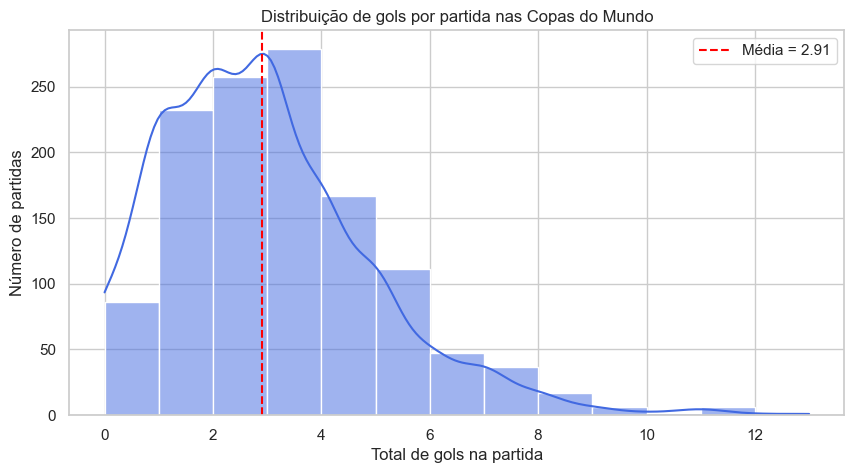

Assimetria (skew): 1.047


In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(df_consolidado['total_goals'], bins=range(0, 13), kde=True, color='royalblue')
plt.axvline(df_consolidado['total_goals'].mean(), color='red', linestyle='--',
            label=f"Média = {df_consolidado['total_goals'].mean():.2f}")
plt.title('Distribuição de gols por partida nas Copas do Mundo')
plt.xlabel('Total de gols na partida')
plt.ylabel('Número de partidas')
plt.legend()
plt.show()

print('Assimetria (skew):', round(df_consolidado['total_goals'].skew(), 3))

# Q12

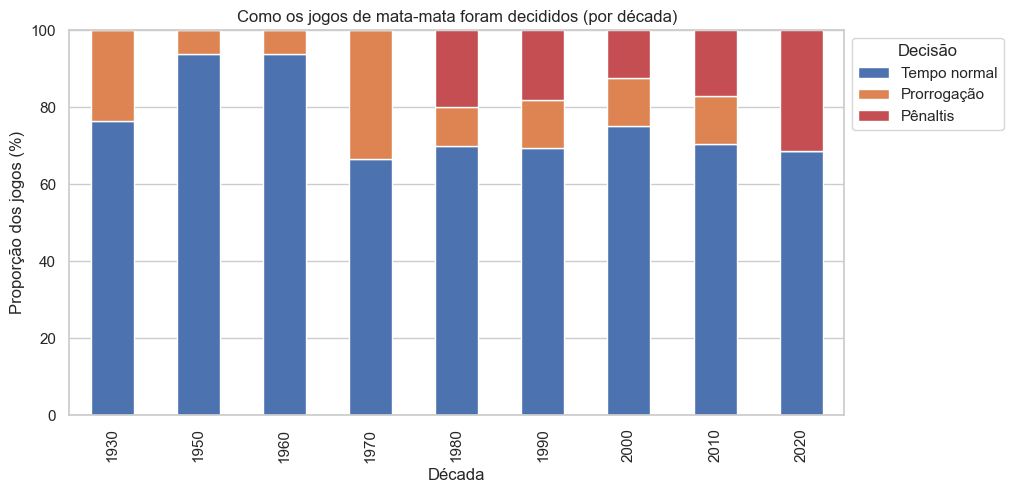

decisao,Tempo normal,Prorrogação,Pênaltis
decada,,,
1930,76.3,23.7,0.0
1950,93.8,6.2,0.0
1960,93.8,6.2,0.0
1970,66.7,33.3,0.0
1980,70.0,10.0,20.0
1990,69.4,12.5,18.1
2000,75.0,12.5,12.5
2010,70.5,12.5,17.0
2020,68.8,0.0,31.2


In [16]:
mata_mata = df_consolidado[df_consolidado['knockout_stage'] == 1].copy()

def tipo_decisao(linha):
    if linha['penalty_shootout'] == 1:
        return 'Pênaltis'
    if linha['extra_time'] == 1:
        return 'Prorrogação'
    return 'Tempo normal'

mata_mata['decisao'] = mata_mata.apply(tipo_decisao, axis=1)
mata_mata['decada'] = (mata_mata['year'] // 10) * 10

# proporcao de cada tipo de decisao por decada
proporcao = pd.crosstab(mata_mata['decada'], mata_mata['decisao'], normalize='index') * 100
proporcao = proporcao[['Tempo normal', 'Prorrogação', 'Pênaltis']]   # ordem logica

proporcao.plot(kind='bar', stacked=True, figsize=(10, 5),
               color=['#4c72b0', '#dd8452', '#c44e52'])
plt.title('Como os jogos de mata-mata foram decididos (por década)')
plt.xlabel('Década')
plt.ylabel('Proporção dos jogos (%)')
plt.legend(title='Decisão', bbox_to_anchor=(1.0, 1.0))
plt.show()

display(proporcao.round(1))

# Q13

/var/folders/ms/r_z2t4213gnd3gn8j_11l3800000gn/T/ipykernel_69951/2130626748.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dados, x='equipe_norm', y='gols_feitos', order=potencias, palette='Set2')


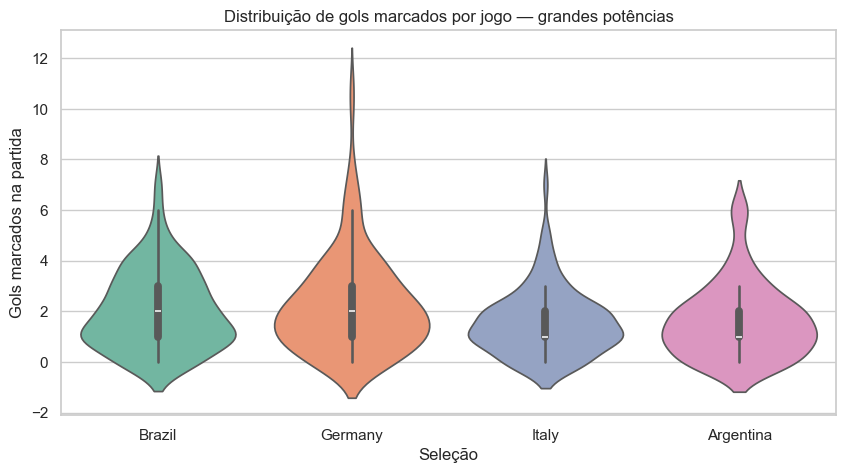

             mean   std
equipe_norm            
Argentina    1.62  1.47
Brazil       2.05  1.56
Germany      2.26  1.94
Italy        1.56  1.29


In [17]:
# unifica Alemanha Ocidental + Alemanha
df_equipes['equipe_norm'] = df_equipes['equipe'].replace({'West Germany': 'Germany'})

potencias = ['Brazil', 'Germany', 'Italy', 'Argentina']
dados = df_equipes[df_equipes['equipe_norm'].isin(potencias)]

plt.figure(figsize=(10, 5))
sns.violinplot(data=dados, x='equipe_norm', y='gols_feitos', order=potencias, palette='Set2')
plt.title('Distribuição de gols marcados por jogo — grandes potências')
plt.xlabel('Seleção')
plt.ylabel('Gols marcados na partida')
plt.show()

print(dados.groupby('equipe_norm')['gols_feitos'].agg(['mean', 'std']).round(2))

# Q14

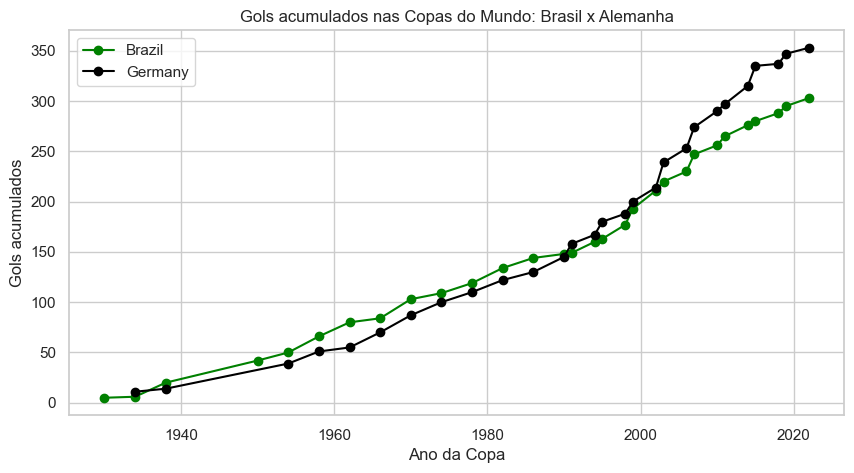

In [18]:
dois = df_equipes[df_equipes['equipe_norm'].isin(['Brazil', 'Germany'])]

# gols por time por ano, depois soma acumulada
gols_ano = dois.groupby(['equipe_norm', 'year'])['gols_feitos'].sum().reset_index()
gols_ano['acumulado'] = gols_ano.groupby('equipe_norm')['gols_feitos'].cumsum()

plt.figure(figsize=(10, 5))
for time, cor in [('Brazil', 'green'), ('Germany', 'black')]:
    d = gols_ano[gols_ano['equipe_norm'] == time]
    plt.plot(d['year'], d['acumulado'], marker='o', label=time, color=cor)

plt.title('Gols acumulados nas Copas do Mundo: Brasil x Alemanha')
plt.xlabel('Ano da Copa')
plt.ylabel('Gols acumulados')
plt.legend()
plt.show()

# Q15

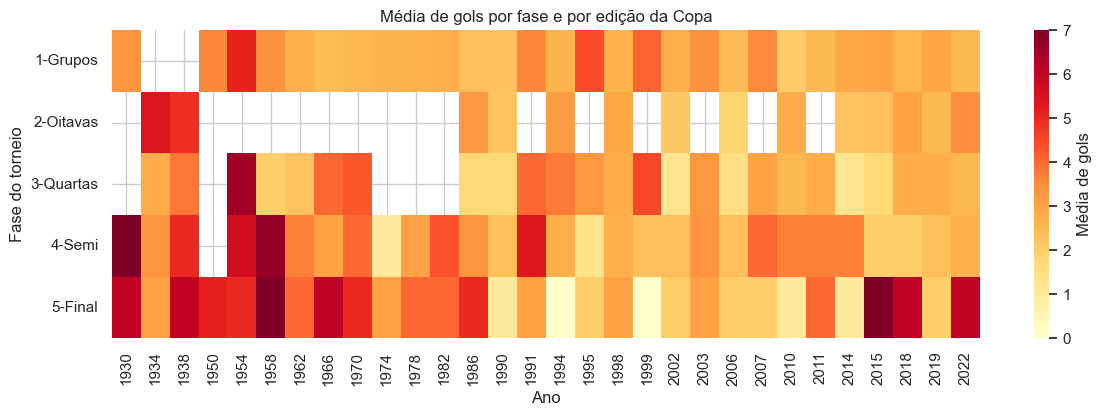

Média de gols por fase (todas as edições):
fase
1-Grupos     2.82
2-Oitavas    3.03
3-Quartas    2.91
4-Semi       3.43
5-Final      3.83
Name: total_goals, dtype: float64


In [19]:
def nome_fase(rank):
    return {0: '1-Grupos', 1: '2-Oitavas', 2: '3-Quartas', 3: '4-Semi', 4: '5-Final'}.get(rank)

base_hm = df_consolidado[df_consolidado['stage_rank'] >= 0].copy()
base_hm['fase'] = base_hm['stage_rank'].apply(nome_fase)

tabela = base_hm.pivot_table(index='fase', columns='year', values='total_goals', aggfunc='mean')

plt.figure(figsize=(14, 4))
sns.heatmap(tabela, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Média de gols'})
plt.title('Média de gols por fase e por edição da Copa')
plt.xlabel('Ano')
plt.ylabel('Fase do torneio')
plt.show()

print('Média de gols por fase (todas as edições):')
print(base_hm.groupby('fase')['total_goals'].mean().round(2))

✅**Parte 4: Correlações de Dados (3 Questões)**

Foco na estatística bivariada, medindo a força e a direção da relação entre duas métricas.

Q16) Correlação Temporal (Pearson/Spearman): Calcule o coeficiente de correlação entre o "Ano da Edição" e o "Total de Gols por Partida". Isso comprova matematicamente a tese de que o futebol ficou mais defensivo e estudado com o passar do tempo?

Q17) Spearman - O futebol está ficando mais equilibrado?
Vamos calcular a correlação entre o passar do tempo (Ano da Copa) e o Equilíbrio (Diferença de Gols). As famosas goleadas acachapantes ficaram no passado?

Q18) Correlação Categórica Cruzada: Calcule a correlação entre a variável binária "Foi para os Pênaltis" (0 ou 1) e o "Estágio do Torneio" (Oitavas, Quartas, Semi, Final). Em qual fase a pressão aponta uma maior tendência histórica de empates?

# Q16

In [20]:
from scipy.stats import pearsonr, spearmanr, pointbiserialr

correlacao_pearson, p_pearson = pearsonr(df_consolidado['year'],df_consolidado['total_goals'])
correlacao_spearman, p_spearman = spearmanr(df_consolidado['year'],df_consolidado['total_goals'])

print('Coeficiente de correlação de Pearson:', round(correlacao_pearson, 3))
print('Coeficiente de correlação de Spearman:', round(correlacao_spearman, 3))

if (correlacao_pearson < 0):
    print('A correlação é negativa\n Significa que, conforme os anos passam, o núm de gols/partida tendem a diminuir\n')
else:
    print('A correlação é positiva. Ou seja, o núm de gols/partida tende a aumentar com o tempo\n')

print('Isso é apenas uma evidencia estatistica de que o futebol ficou mais defensivo, não uma prova definitiva')

Coeficiente de correlação de Pearson: -0.18
Coeficiente de correlação de Spearman: -0.128
A correlação é negativa
 Significa que, conforme os anos passam, o núm de gols/partida tendem a diminuir

Isso é apenas uma evidencia estatistica de que o futebol ficou mais defensivo, não uma prova definitiva


# Q17

In [21]:
correlacao_equilibrio, p_eq = spearmanr(df_consolidado['year'],df_consolidado['goal_difference'])

print('Coeficiente de correlação de Spearman (ano X diferença de gols):', round(correlacao_equilibrio, 3), '(p-valor =', round(p_eq, 4), ')')

if (correlacao_equilibrio < 0):
    print('A correlação é negativa\nSignifica que, conforme os anos passam, a diferença de gols tende a diminuir')
    print('Ou seja, os jogos estão ficando mais equilibrados e as goleadas grandes estão cada vez mais raras.')
else:
    print('A correlação é positiva. Ou seja, a diferença de gols nao diminuiu com o tempo\n')

Coeficiente de correlação de Spearman (ano X diferença de gols): -0.069 (p-valor = 0.0141 )
A correlação é negativa
Significa que, conforme os anos passam, a diferença de gols tende a diminuir
Ou seja, os jogos estão ficando mais equilibrados e as goleadas grandes estão cada vez mais raras.


# Q18

In [22]:
mata_mata = df_consolidado[df_consolidado['knockout_stage'] == 1].copy()
nome_fase = {1: 'Oitavas', 2: 'Quartas', 3: 'Semifinal', 4: 'Final'}
mata_mata = mata_mata[mata_mata['stage_rank'].isin(nome_fase.keys())].copy()
mata_mata['fase'] = mata_mata['stage_rank'].map(nome_fase)

#Tabela de proporcao
tabela_penaltis = pd.crosstab(mata_mata['fase'], mata_mata['penalty_shootout'], normalize='index') * 100
tabela_penaltis.columns = ['Não foi a penaltis (%)', 'Foi a penaltis (%)']
ordem_fases = ['Oitavas', 'Quartas', 'Semifinal', 'Final']
tabela_penaltis = tabela_penaltis.reindex(ordem_fases)

print("Tabela de proporção de penaltis por fase:")
display(tabela_penaltis.round(1))


#Correlaçao
corr_ponto_bisserial, p_pb = pointbiserialr(mata_mata['penalty_shootout'], mata_mata['stage_rank'])
print('\nCorrelação ponto-bisserial (estagio X penaltis):', round(corr_ponto_bisserial, 3), '(p-valor =', round(p_pb, 4), ')')

fase_mais_penaltis = tabela_penaltis['Foi a penaltis (%)'].idxmax()
print('\nFase com maior tendência histórica a terminar empatada e ir para os penaltis:', fase_mais_penaltis)

Tabela de proporção de penaltis por fase:


,Não foi a penaltis (%),Foi a penaltis (%)
fase,,
Oitavas,87.6,12.4
Quartas,82.4,17.6
Semifinal,92.7,7.3
Final,82.8,17.2



Correlação ponto-bisserial (estagio X penaltis): -0.015 (p-valor = 0.7936 )

Fase com maior tendência histórica a terminar empatada e ir para os penaltis: Quartas


✅**Parte 5: Probabilidade e Estatística Avançada (3 Questões)**

Foco em inferência, valor esperado e distribuições utilizando a biblioteca scipy.stats.

Q19) Distribuição de Poisson e a Realidade do 0x0: Gols no futebol costumam modelar perfeitamente uma Distribuição de Poisson. Calcule o Valor Esperado ($\lambda$) de gols por partida em toda a história. Usando esse $\lambda$, qual é a probabilidade teórica de um jogo terminar em 0x0? Como essa probabilidade matemática se compara com a porcentagem real de jogos que terminaram 0x0 na sua base?

Q20) Probabilidade Condicional (Teorema de Bayes empírico): Dado que uma partida de mata-mata termina empatada no tempo normal e vai para a prorrogação, qual é a probabilidade condicional dessa mesma partida acabar indo para as cobranças de pênaltis?

Q21) Teste de Hipótese (T-Test): O dono da casa altera o padrão do jogo? Usaremos o Teste T (Welch) para verificar se há uma diferença estatisticamente significativa na média de gols quando o país anfitrião está em campo.

# Q19

In [23]:
from scipy.stats import poisson, ttest_ind

lamb = df_consolidado['total_goals'].mean()
print('Media de gols por partida (em toda a historia das copas):', round(lamb, 3))

# Probabilidade teorica de 0 gols
prob_teorica_0 = poisson.pmf(0, lamb)
print('Probabilidade teorica de uma partida terminar em 0x0 (Poisson):', str(round(prob_teorica_0 * 100 , 2)) + '%')

# Percentual real de jogos 0x0 da base de dados
pct_real_0 = (df_consolidado['total_goals'] == 0).mean() * 100
print('Percentual real de jogos 0x0 na base:', str(round(pct_real_0, 2)) + '%')

print('\nComparando: o modelo de Poisson:')
if (prob_teorica_0 * 100 < pct_real_0):
  print('ele subestima um pouco a chance de 0x0 em relação ao que realmente aconteceu.')
else :
  print('ele sobrestima um pouco a chance de 0x0 em relação ao que realmente aconteceu.')

print('Isso é esperado pois a poisson assume que os times marcam de forama independente e aletoria, mas no futebol real existem outros fatores que influenciam')


Media de gols por partida (em toda a historia das copas): 2.914
Probabilidade teorica de uma partida terminar em 0x0 (Poisson): 5.42%
Percentual real de jogos 0x0 na base: 6.89%

Comparando: o modelo de Poisson:
ele subestima um pouco a chance de 0x0 em relação ao que realmente aconteceu.
Isso é esperado pois a poisson assume que os times marcam de forama independente e aletoria, mas no futebol real existem outros fatores que influenciam


# Q20

In [24]:
prorrogacao = df_consolidado[df_consolidado['extra_time'] == 1]

n_prorrogacao = prorrogacao.shape[0]
n_prorrogacao_e_penaltis = prorrogacao[prorrogacao['penalty_shootout'] == 1].shape[0]

p_penaltis_dado_prorrogacao = n_prorrogacao_e_penaltis / n_prorrogacao

print('Jogos que foram para a prorrogação:', n_prorrogacao)
print('Desses jogos, foram para penaltis:', n_prorrogacao_e_penaltis)
print('P(Penaltis | Prorrogação) =', round(p_penaltis_dado_prorrogacao, 3), '->', str(round(p_penaltis_dado_prorrogacao * 100, 1)) + '%')

print('\nOu seja: dado um jogo que empatou no tempo normal e foi para a prorrogação,')
print('há quase', str(round(p_penaltis_dado_prorrogacao * 100)) + '% de chance de ele ainda continuar empatado e ir para os pênaltis.')

Jogos que foram para a prorrogação: 88
Desses jogos, foram para penaltis: 42
P(Penaltis | Prorrogação) = 0.477 -> 47.7%

Ou seja: dado um jogo que empatou no tempo normal e foi para a prorrogação,
há quase 48% de chance de ele ainda continuar empatado e ir para os pênaltis.


# Q21

In [25]:
filtro_anfitriao = (
    (df_consolidado['host_country'] == df_consolidado['home_team_name']) |
    (df_consolidado['host_country'] == df_consolidado['away_team_name'])
)

jogos_com_anfitriao = df_consolidado[filtro_anfitriao]
jogos_sem_anfitriao  = df_consolidado[~filtro_anfitriao]

media_com_anfitriao = jogos_com_anfitriao['total_goals'].mean()
media_sem_anfitriao = jogos_sem_anfitriao['total_goals'].mean()

print('Média de gols COM o anfitrião em campo:', round(media_com_anfitriao, 2), '(n =', jogos_com_anfitriao.shape[0], ')')
print('Média de gols nos demais jogos:        ', round(media_sem_anfitriao, 2), '(n =', jogos_sem_anfitriao.shape[0], ')')

t_stat, p_valor = ttest_ind(jogos_com_anfitriao['total_goals'], jogos_sem_anfitriao['total_goals'], equal_var=False)
print('\nEstatística t (Welch):', round(t_stat, 3))
print('p-valor:', round(p_valor, 4))

alpha = 0.05
if p_valor < alpha:
    print('\nComo o p-valor é menor que', alpha, ', a diferença é estatisticamente significativa.')
    print('Ou seja: o anfitrião em campo realmente parece mudar o padrão de gols')
else:
    print('\nComo o p-valor é maior ou igual a', alpha, ', a diferença não é estatisticamente significativa.')
    print('Ou seja: não ha evidencia de que jogar com o anfitrião em campo mude a média de gols da partida')

Média de gols COM o anfitrião em campo: 2.9 (n = 148 )
Média de gols nos demais jogos:         2.92 (n = 1100 )

Estatística t (Welch): -0.102
p-valor: 0.9188

Como o p-valor é maior ou igual a 0.05 , a diferença não é estatisticamente significativa.
Ou seja: não ha evidencia de que jogar com o anfitrião em campo mude a média de gols da partida


✅**Parte 6 (extra - para ilustração de um pouco de IA): Inteligência Artificial Simples e XAI (3 Questões)**

Foco na transição da análise para a modelagem preditiva utilizando scikit-learn e explicabilidade com shap.

Q22) Regressão Linear Múltipla (Previsão Contínua): Construa um modelo de regressão linear simples para prever o Total de Gols de uma partida futura utilizando as exatas variáveis independentes (features) exigidas pela questão.

Q23) egressão Logística (Classificação Binária): Treine um modelo para prever a "Vitória do Mandante". Use o histórico das seleções (Média de gols pró da equipe na edição, Média de gols sofridos) para calcular a probabilidade de vitória de uma seleção contra a outra (ex: Brasil x Sérvia).

Q24) Explicabilidade de Modelo (XAI com SHAP ou Feature Importance): Pegue o modelo de Regressão Logística ou crie uma Árvore de Decisão (DecisionTreeClassifier) baseada na questão 23. Utilize a biblioteca SHAP (ou o atributo feature_importances_) para responder e criar um gráfico: O que pesa mais para o algoritmo decidir o vencedor? É a força ofensiva (gols feitos historicamente) ou a segurança defensiva (menos gols sofridos)?

In [26]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score

# força de cada time em cada edição (ataque = gols feitos, defesa = gols sofridos)
casa = df_consolidado[['tournament_id', 'home_team_name', 'home_team_score', 'away_team_score']].rename(
    columns={'home_team_name': 'equipe', 'home_team_score': 'gf', 'away_team_score': 'gs'})
fora = df_consolidado[['tournament_id', 'away_team_name', 'away_team_score', 'home_team_score']].rename(
    columns={'away_team_name': 'equipe', 'away_team_score': 'gf', 'home_team_score': 'gs'})
longo = pd.concat([casa, fora])

forca = longo.groupby(['tournament_id', 'equipe']).agg(
    ataque=('gf', 'mean'), defesa=('gs', 'mean')).reset_index()

# traz a força do mandante e do visitante para cada partida
dados_ml = df_consolidado.merge(
    forca.rename(columns={'equipe': 'home_team_name', 'ataque': 'atk_home', 'defesa': 'def_home'}),
    on=['tournament_id', 'home_team_name'], how='left')
dados_ml = dados_ml.merge(
    forca.rename(columns={'equipe': 'away_team_name', 'ataque': 'atk_away', 'defesa': 'def_away'}),
    on=['tournament_id', 'away_team_name'], how='left')

features = ['atk_home', 'def_home', 'atk_away', 'def_away']
dados_ml = dados_ml.dropna(subset=features + ['total_goals'])
print('Partidas utilizadas no modelo:', len(dados_ml))

Partidas utilizadas no modelo: 1248


# Q22

In [27]:
X = dados_ml[features]
y = dados_ml['total_goals']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

modelo_lin = LinearRegression().fit(X_tr, y_tr)
y_prev = modelo_lin.predict(X_te)

print('R² no teste:', round(r2_score(y_te, y_prev), 3))
print('\nCoeficientes (quanto cada feature soma ao total de gols previsto):')
for f, c in zip(features, modelo_lin.coef_):
    print(f'  {f}: {c:+.3f}')

R² no teste: 0.455

Coeficientes (quanto cada feature soma ao total de gols previsto):
  atk_home: +0.646
  def_home: +0.514
  atk_away: +0.623
  def_away: +0.858


# Q23

In [28]:
dados_ml['vitoria_mandante'] = (dados_ml['home_team_score'] > dados_ml['away_team_score']).astype(int)

X = dados_ml[features]
y = dados_ml['vitoria_mandante']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

modelo_log = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
print('Acurácia no teste:', round(accuracy_score(y_te, modelo_log.predict(X_te)), 3))

# exemplo prático: Brasil x Sérvia em 2022
def forca_em(team, edicao='WC-2022'):
    linha = forca[(forca['tournament_id'] == edicao) & (forca['equipe'] == team)]
    return linha[['ataque', 'defesa']].values[0]

br = forca_em('Brazil')
sr = forca_em('Serbia')
print(f'\nBrasil 2022  -> ataque {br[0]:.2f}, defesa {br[1]:.2f}')
print(f'Sérvia 2022  -> ataque {sr[0]:.2f}, defesa {sr[1]:.2f}')

confronto = [[br[0], br[1], sr[0], sr[1]]]   # Brasil como mandante
prob = modelo_log.predict_proba(confronto)[0, 1]
print(f'\nProbabilidade do Brasil vencer a Sérvia: {prob*100:.1f}%')

Acurácia no teste: 0.785

Brasil 2022  -> ataque 1.60, defesa 0.60
Sérvia 2022  -> ataque 1.67, defesa 2.67

Probabilidade do Brasil vencer a Sérvia: 88.5%


/Users/gabrielreis/.pyenv/versions/3.14.5/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Q24

Acurácia do Random Forest: 0.721


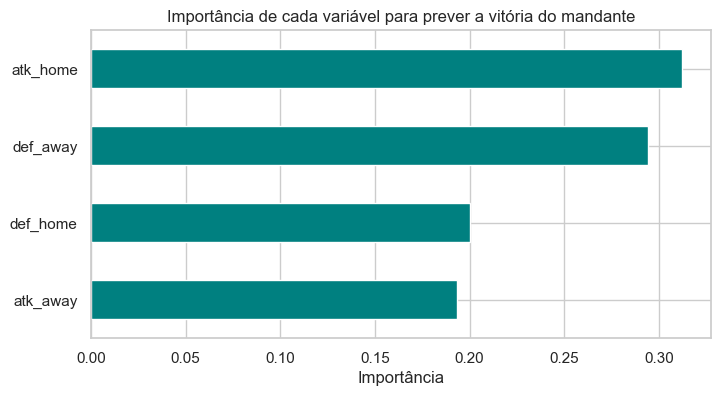

atk_away    0.193
def_home    0.200
def_away    0.294
atk_home    0.312
dtype: float64


In [29]:
floresta = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_tr, y_tr)

importancias = pd.Series(floresta.feature_importances_, index=features).sort_values()
print('Acurácia do Random Forest:', round(accuracy_score(y_te, floresta.predict(X_te)), 3))

plt.figure(figsize=(8, 4))
importancias.plot(kind='barh', color='teal')
plt.title('Importância de cada variável para prever a vitória do mandante')
plt.xlabel('Importância')
plt.show()
print(importancias.round(3))

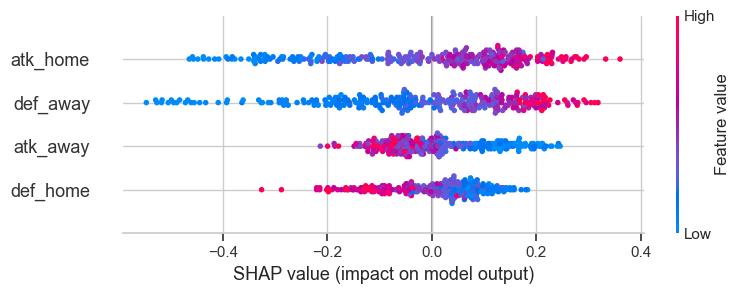

In [30]:
# Tentativa de grafico SHAP
try:
    import shap
    explainer = shap.TreeExplainer(floresta)
    shap_values = explainer.shap_values(X_te)
    # versoes novas do SHAP retornam array 3D (amostras, features, classes) -> pegamos a classe 1
    valores = shap_values[:, :, 1] if getattr(shap_values, 'ndim', 2) == 3 else shap_values
    shap.summary_plot(valores, X_te, feature_names=features, show=True)
except Exception as e:
    print('SHAP não pôde ser gerado neste ambiente:', e)
    print('Sem problemas: a análise pelo feature_importances_ acima já responde a questão.')

**Quem faz mais gol entre copa feminina e masculina** ?

Copa Masculina -> jogos: 964 | média de gols por partida: 2.82
Copa Feminina  -> jogos: 284 | média de gols por partida: 3.23

Teste T de Welch -> t = -2.97 | p-valor = 0.0031
Como p < 0.05, a diferença é significativa: a Copa Feminina faz mais gols por partida.


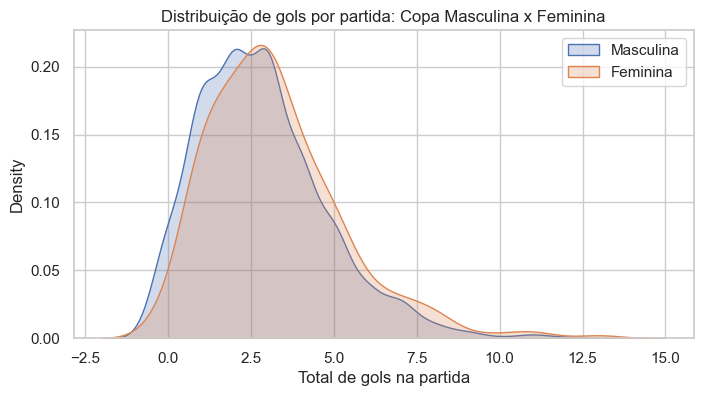

In [31]:
# A base do projeto traz tanto a Copa Masculina quanto a Feminina (coluna tournament_name).
# Vamos comparar a média de gols por partida entre as duas.
from scipy.stats import ttest_ind

masculina = df_consolidado[df_consolidado['tournament_name'].str.contains('Men')]
feminina  = df_consolidado[df_consolidado['tournament_name'].str.contains('Women')]

media_masc = masculina['total_goals'].mean()
media_fem  = feminina['total_goals'].mean()

print('Copa Masculina -> jogos:', masculina.shape[0], '| média de gols por partida:', round(media_masc, 2))
print('Copa Feminina  -> jogos:', feminina.shape[0],  '| média de gols por partida:', round(media_fem, 2))

# Teste T de Welch para checar se a diferença é estatisticamente significativa
t_stat, p_valor = ttest_ind(masculina['total_goals'], feminina['total_goals'], equal_var=False)
print('\nTeste T de Welch -> t =', round(t_stat, 3), '| p-valor =', round(p_valor, 4))

if p_valor < 0.05:
    mais_gols = 'Feminina' if media_fem > media_masc else 'Masculina'
    print('Como p < 0.05, a diferença é significativa: a Copa', mais_gols, 'faz mais gols por partida.')
else:
    print('Como p >= 0.05, não há diferença estatisticamente significativa entre as duas.')

# Gráfico comparando as distribuições de gols
plt.figure(figsize=(8, 4))
sns.kdeplot(masculina['total_goals'], label='Masculina', fill=True)
sns.kdeplot(feminina['total_goals'],  label='Feminina',  fill=True)
plt.title('Distribuição de gols por partida: Copa Masculina x Feminina')
plt.xlabel('Total de gols na partida')
plt.legend()
plt.show()

*** Ranking de titulos mundias para futebol masculino ***

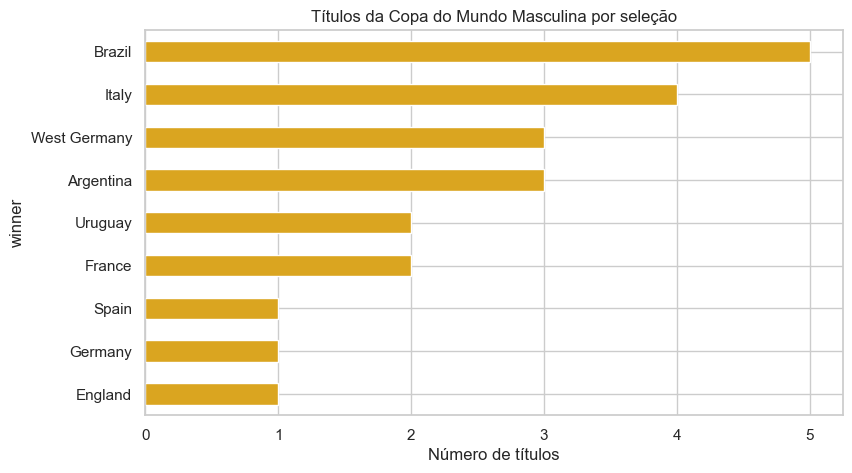

winner
Brazil          5
Italy           4
Argentina       3
West Germany    3
France          2
Uruguay         2
England         1
Germany         1
Spain           1
dtype: int64


In [32]:
titulos = (df_torneios[df_torneios['tournament_name'].str.contains('Men')]
           .groupby('winner').size().sort_values(ascending=False))

plt.figure(figsize=(9, 5))
titulos.sort_values().plot(kind='barh', color='goldenrod')
plt.title('Títulos da Copa do Mundo Masculina por seleção')
plt.xlabel('Número de títulos'); plt.show()
print(titulos)

#### Rede de Rivalidades em **D3.js** ( Usando D3 apresentado pelo Adriano na Sala )

In [33]:
import json
import html as _html
from IPython.display import HTML, display

# ---------- 1) Monta os dados da rede com pandas (Copa Masculina) ----------
rede = df_consolidado[df_consolidado['tournament_name'].str.contains('Men')].copy()
rede['home'] = rede['home_team_name'].replace({'West Germany': 'Germany'})
rede['away'] = rede['away_team_name'].replace({'West Germany': 'Germany'})
rede['par']  = rede.apply(lambda r: tuple(sorted([str(r['home']), str(r['away'])])), axis=1)

contagem = rede['par'].value_counts()
links = [{'source': a, 'target': b, 'value': int(v)}
         for (a, b), v in contagem.items() if v >= 3]      # so rivalidades com 3+ jogos

jogos = rede['home'].value_counts().add(rede['away'].value_counts(), fill_value=0).astype(int)
titulos = (df_torneios[df_torneios['tournament_name'].str.contains('Men')]['winner']
           .replace({'West Germany': 'Germany'}).value_counts())

times = sorted(set(l['source'] for l in links) | set(l['target'] for l in links))
nodes = [{'id': x, 'games': int(jogos.get(x, 0)), 'titles': int(titulos.get(x, 0))} for x in times]
print(f'Rede de rivalidades: {len(nodes)} seleções e {len(links)} confrontos (com 3+ jogos)')

dados_json = json.dumps({'nodes': nodes, 'links': links})

# ---------- 2) Página HTML + D3.js ----------
# Largura/altura FIXAS e posições "presas" dentro da área (clamp) para o grafo
# nunca sair da moldura nem ficar cortado quando o notebook é exportado para PDF.
template = r"""<!DOCTYPE html>
<html><head><meta charset="utf-8">
<script src="https://d3js.org/d3.v7.min.js"></script>
<style>
  body { margin:0; font-family:Arial,Helvetica,sans-serif; background:#fafafa; }
  .tip { position:absolute; background:#222; color:#fff; padding:6px 9px; border-radius:5px;
         font-size:12px; pointer-events:none; opacity:0; }
  .lbl { fill:#333; pointer-events:none; font-size:10px; }
  .lbl.big { font-size:12px; font-weight:bold; }
  .titulo { font-size:14px; font-weight:bold; fill:#333; }
</style></head>
<body>
<div class="tip" id="tip"></div>
<svg id="svg"></svg>
<script>
const graph = __DATA__;
const W = 540, H = 470, TOP = 38, PAD = 6;
const svg = d3.select("#svg").attr("width", W).attr("height", H);
const tip = d3.select("#tip");

svg.append("text").attr("class","titulo").attr("x",14).attr("y",24)
   .text("Rede de Rivalidades da Copa do Mundo (confrontos com 3+ jogos)");

const maxGames  = d3.max(graph.nodes, d => d.games);
const maxTitles = d3.max(graph.nodes, d => d.titles);
const maxValue  = d3.max(graph.links, d => d.value);
const rScale = d3.scaleSqrt().domain([0, maxGames]).range([5, 26]);
const wScale = d3.scaleLinear().domain([3, maxValue]).range([1, 7]);
const champ  = d3.scaleSequential(d3.interpolateYlOrRd).domain([-1, maxTitles]);

const link = svg.append("g").attr("stroke", "#bbb").selectAll("line")
   .data(graph.links).join("line")
   .attr("stroke-width", d => wScale(d.value))
   .attr("stroke-opacity", 0.5);
link.append("title").text(d => d.value + " jogos");

const node = svg.append("g").selectAll("circle")
   .data(graph.nodes).join("circle")
   .attr("r", d => rScale(d.games))
   .attr("fill", d => d.titles > 0 ? champ(d.titles) : "#6baed6")
   .attr("stroke", "#fff").attr("stroke-width", 1.5)
   .style("cursor", "grab")
   .call(d3.drag().on("start", started).on("drag", dragged).on("end", ended));

const label = svg.append("g").selectAll("text")
   .data(graph.nodes).join("text")
   .attr("class", d => d.games >= 60 ? "lbl big" : "lbl")
   .attr("text-anchor", "middle")
   .text(d => d.games >= 25 ? d.id : "");

node.on("mousemove", (e, d) => {
      tip.style("opacity", 1)
         .html("<b>" + d.id + "</b><br>" + d.games + " jogos<br>" + d.titles + " titulo(s)")
         .style("left", (e.pageX + 14) + "px").style("top", (e.pageY - 10) + "px");
      link.attr("stroke", l => (l.source.id === d.id || l.target.id === d.id) ? "#e6550d" : "#ccc")
          .attr("stroke-opacity", l => (l.source.id === d.id || l.target.id === d.id) ? 0.9 : 0.08);
   })
   .on("mouseout", () => {
      tip.style("opacity", 0);
      link.attr("stroke", "#bbb").attr("stroke-opacity", 0.5);
   });

function clamp(d) {
   const r = rScale(d.games) + PAD;
   d.x = Math.max(r, Math.min(W - r, d.x));
   d.y = Math.max(TOP + r, Math.min(H - r, d.y));
}

const sim = d3.forceSimulation(graph.nodes)
   .force("link", d3.forceLink(graph.links).id(d => d.id).distance(d => 110 - d.value * 4).strength(0.35))
   .force("charge", d3.forceManyBody().strength(-170))
   .force("center", d3.forceCenter(W / 2, (H + TOP) / 2))
   .force("collide", d3.forceCollide().radius(d => rScale(d.games) + 4))
   .on("tick", () => {
      graph.nodes.forEach(clamp);
      link.attr("x1", d => d.source.x).attr("y1", d => d.source.y)
          .attr("x2", d => d.target.x).attr("y2", d => d.target.y);
      node.attr("cx", d => d.x).attr("cy", d => d.y);
      label.attr("x", d => d.x).attr("y", d => d.y - rScale(d.games) - 3);
   });

function started(e, d) { if (!e.active) sim.alphaTarget(0.3).restart(); d.fx = d.x; d.fy = d.y; }
function dragged(e, d) { d.fx = e.x; d.fy = e.y; }
function ended(e, d)   { if (!e.active) sim.alphaTarget(0);  d.fx = null; d.fy = null; }
</script>
</body></html>"""

# injeta os dados e exibe dentro de um iframe de tamanho fixo (isola o JavaScript)
pagina = template.replace("__DATA__", dados_json)
display(HTML('<iframe srcdoc="' + _html.escape(pagina) + '" width="560" height="498" style="border:none;"></iframe>'))

Rede de rivalidades: 35 seleções e 77 confrontos (com 3+ jogos)


/Users/gabrielreis/.pyenv/versions/3.14.5/lib/python3.14/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")
